# Generative AI for Data Science Lab

## Scenario 1: Retail Inventory Analysis

### Your Prompt

Act as a senior data scientist and retail inventory analyst. Your task is to develop a robust Python solution for analyzing inventory turnover for a retail chain.

The data is stored in a pandas DataFrame called inventory_df with these columns:

- product_id: unique product identifier
- category: product category
- stock_level: current quantity of the product in stock
- last_restock_date: date the product was last restocked
- sales_last_30_days: number of units sold during the last 30 days
- supplier_lead_time: number of days required for the supplier to deliver
- unit_cost: cost per unit

Develop a complete, well-documented Python solution that:

1. Validates that all required columns exist.
2. Checks for missing, invalid, or negative values in relevant numeric columns.
3. Converts last_restock_date into a proper datetime format and handles invalid dates safely.
4. Calculates an inventory turnover rate for each product using sales over the last 30 days relative to available inventory.
5. Identifies slow-moving products using a clearly explained and reasonable threshold.
6. Estimates the number of days of inventory remaining based on recent sales.
7. Predicts products that may experience a stockout before the supplier can deliver new inventory.
8. Handles edge cases such as zero sales, zero stock, missing values, and invalid dates.
9. Creates useful visualizations showing inventory turnover, slow-moving products, and potential stockout risks.
10. Uses pandas and matplotlib/seaborn where appropriate.
11. Organizes the solution into reusable functions with clear docstrings.
12. Includes comments explaining important calculations and assumptions.
13. Produces a final DataFrame containing the important calculated metrics and risk classifications.

Before writing the code, briefly explain the assumptions behind the inventory turnover and stockout calculations. Then provide the complete Python implementation.

Act as an analytical reviewer as well as a programmer: check your generated solution for logical errors, inappropriate calculations, and edge cases before presenting the final code.


### Generated Code


In [8]:
import pandas as pd

inventory_df = pd.DataFrame({
    "product_id": [101, 102, 103, 104, 105],
    "category": ["Electronics", "Clothing", "Groceries", "Electronics", "Clothing"],
    "stock_level": [50, 120, 200, 25, 80],
    "last_restock_date": [
        "2026-08-01",
        "2026-07-25",
        "2026-08-05",
        "2026-07-20",
        "2026-08-10"
    ],
    "sales_last_30_days": [40, 15, 180, 35, 5],
    "supplier_lead_time": [7, 14, 5, 10, 20],
    "unit_cost": [500, 1500, 200, 800, 1200]
})

inventory_df

,product_id,category,stock_level,last_restock_date,sales_last_30_days,supplier_lead_time,unit_cost
0,101,Electronics,50,2026-08-01,40,7,500
1,102,Clothing,120,2026-07-25,15,14,1500
2,103,Groceries,200,2026-08-05,180,5,200
3,104,Electronics,25,2026-07-20,35,10,800
4,105,Clothing,80,2026-08-10,5,20,1200


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def validate_inventory_data(inventory_df):
    """
    Validate the inventory DataFrame before performing analysis.

    Parameters
    ----------
    inventory_df : pandas.DataFrame
        DataFrame containing retail inventory information.

    Returns
    -------
    pandas.DataFrame
        A cleaned copy of the input DataFrame.
    """

    required_columns = [
        "product_id",
        "category",
        "stock_level",
        "last_restock_date",
        "sales_last_30_days",
        "supplier_lead_time",
        "unit_cost"
    ]

    # Check that the input is a DataFrame
    if not isinstance(inventory_df, pd.DataFrame):
        raise TypeError("inventory_df must be a pandas DataFrame.")

    # Check for missing columns
    missing_columns = [
        column for column in required_columns
        if column not in inventory_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    # Create a copy so the original data is not changed
    df = inventory_df.copy()

    # Convert date column safely
    df["last_restock_date"] = pd.to_datetime(
        df["last_restock_date"],
        errors="coerce"
    )

    # Numeric columns
    numeric_columns = [
        "stock_level",
        "sales_last_30_days",
        "supplier_lead_time",
        "unit_cost"
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

    # Check for negative values
    for column in numeric_columns:
        negative_values = (df[column] < 0).sum()

        if negative_values > 0:
            print(
                f"Warning: {negative_values} negative values found "
                f"in {column}. They will be treated as missing."
            )

            df.loc[df[column] < 0, column] = np.nan

    # Display validation information
    print("Data validation completed.")
    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")
    print("\nMissing values:")
    print(df[required_columns].isnull().sum())

    return df


def calculate_inventory_metrics(df):
    """
    Calculate inventory turnover and stockout-related metrics.

    Because beginning inventory is not provided, the 30-day turnover
    is calculated as a proxy using sales during the last 30 days
    divided by current stock level.
    """

    result = df.copy()

    # 30-day inventory turnover proxy
    result["inventory_turnover"] = np.where(
        result["stock_level"] > 0,
        result["sales_last_30_days"] / result["stock_level"],
        np.nan
    )

    # Average daily sales during the last 30 days
    result["average_daily_sales"] = (
        result["sales_last_30_days"] / 30
    )

    # Estimated number of days remaining
    result["days_of_inventory_remaining"] = np.where(
        result["average_daily_sales"] > 0,
        result["stock_level"] / result["average_daily_sales"],
        np.inf
    )

    # Predict potential stockout before supplier delivery
    result["potential_stockout"] = (
        result["days_of_inventory_remaining"]
        <= result["supplier_lead_time"]
    )

    # Identify slow-moving products
    # Products selling less than 1 unit per day are classified as slow-moving.
    result["slow_moving"] = (
        result["average_daily_sales"] < 1
    )

    # Calculate inventory value
    result["inventory_value"] = (
        result["stock_level"] * result["unit_cost"]
    )

    # Risk classification
    result["stockout_risk"] = np.select(
        [
            result["days_of_inventory_remaining"]
            <= result["supplier_lead_time"],

            result["days_of_inventory_remaining"]
            <= result["supplier_lead_time"] * 1.5
        ],
        [
            "High Risk",
            "Medium Risk"
        ],
        default="Low Risk"
    )

    return result


# Validate the data
validated_inventory = validate_inventory_data(inventory_df)

# Calculate inventory metrics
inventory_analysis = calculate_inventory_metrics(
    validated_inventory
)

# Display the results
inventory_analysis.head()

Data validation completed.
Rows: 5
Columns: 7

Missing values:
product_id            0
category              0
stock_level           0
last_restock_date     0
sales_last_30_days    0
supplier_lead_time    0
unit_cost             0
dtype: int64


,product_id,category,stock_level,last_restock_date,sales_last_30_days,supplier_lead_time,unit_cost,inventory_turnover,average_daily_sales,days_of_inventory_remaining,potential_stockout,slow_moving,inventory_value,stockout_risk
0,101,Electronics,50,2026-08-01,40,7,500,0.8000,1.333333,37.500000,False,False,25000,Low Risk
1,102,Clothing,120,2026-07-25,15,14,1500,0.1250,0.500000,240.000000,False,True,180000,Low Risk
2,103,Groceries,200,2026-08-05,180,5,200,0.9000,6.000000,33.333333,False,False,40000,Low Risk
3,104,Electronics,25,2026-07-20,35,10,800,1.4000,1.166667,21.428571,False,False,20000,Low Risk
4,105,Clothing,80,2026-08-10,5,20,1200,0.0625,0.166667,480.000000,False,True,96000,Low Risk


### Follow-up Prompt 2 — Review and Improve the Analysis

I tested the generated inventory analysis code using a five-product test DataFrame.

The code successfully validated the data and produced these metrics:

* inventory_turnover
* average_daily_sales
* days_of_inventory_remaining
* potential_stockout
* slow_moving
* inventory_value
* stockout_risk

The results classify products 102 and 105 as slow-moving, while all five products are classified as having low stockout risk.

Review the logic and explain whether these classifications are reasonable.

In particular:

1. Check whether the inventory turnover calculation is appropriate given that beginning inventory is unavailable.
2. Check whether the slow-moving threshold of less than 1 unit sold per day is appropriate and explain the assumption.
3. Check whether the stockout calculation correctly compares inventory remaining with supplier lead time.
4. Check whether the risk categories should include additional information such as a safety-stock buffer.
5. Identify any calculations that could be misleading.
6. Suggest improvements while keeping the solution simple enough for a beginner data-science project.

Then provide an improved version of the calculation functions and explain the changes.


### Visualizations

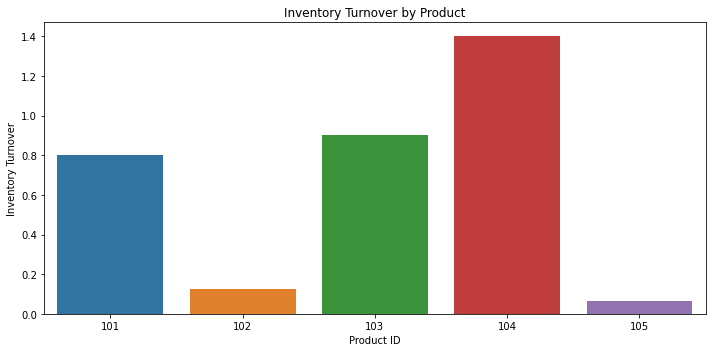

In [10]:
# Visualization 1: Inventory Turnover by Product

plt.figure(figsize=(10, 5))

sns.barplot(
    data=inventory_analysis,
    x="product_id",
    y="inventory_turnover"
)

plt.title("Inventory Turnover by Product")
plt.xlabel("Product ID")
plt.ylabel("Inventory Turnover")
plt.tight_layout()
plt.show()

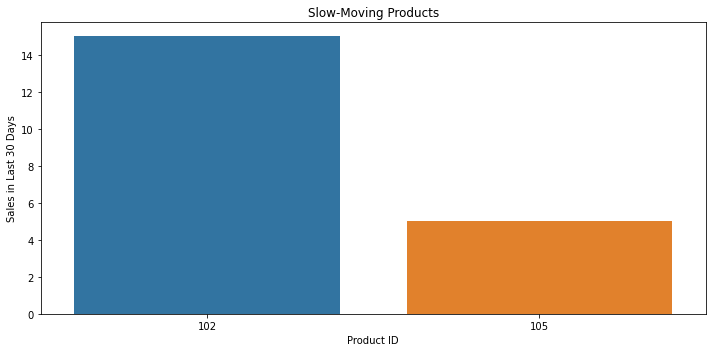

In [11]:
# Visualization 2: Slow-Moving Products

slow_moving_products = inventory_analysis[
    inventory_analysis["slow_moving"] == True
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=slow_moving_products,
    x="product_id",
    y="sales_last_30_days"
)

plt.title("Slow-Moving Products")
plt.xlabel("Product ID")
plt.ylabel("Sales in Last 30 Days")
plt.tight_layout()
plt.show()

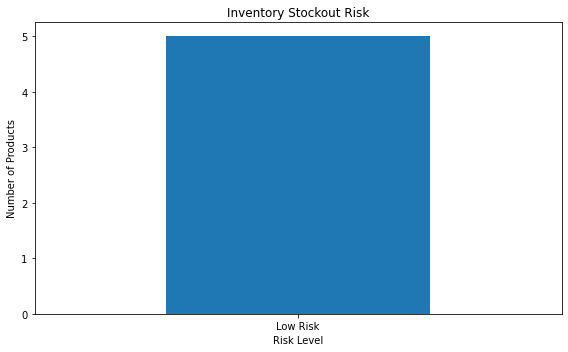

In [12]:
# Visualization 3: Stockout Risk

risk_counts = inventory_analysis["stockout_risk"].value_counts()

plt.figure(figsize=(8, 5))

risk_counts.plot(kind="bar")

plt.title("Inventory Stockout Risk")
plt.xlabel("Risk Level")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

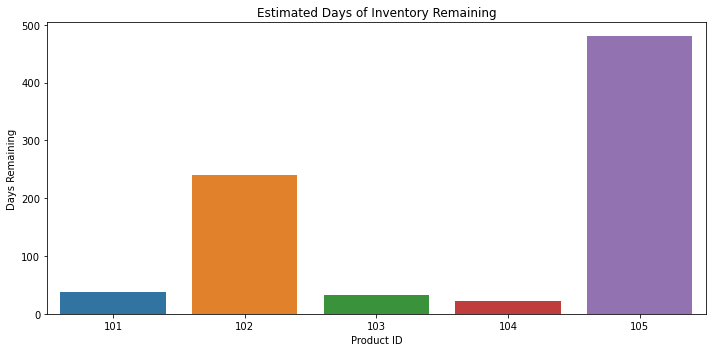

In [13]:
# Visualization 4: Days of Inventory Remaining

plt.figure(figsize=(10, 5))

sns.barplot(
    data=inventory_analysis,
    x="product_id",
    y="days_of_inventory_remaining"
)

plt.title("Estimated Days of Inventory Remaining")
plt.xlabel("Product ID")
plt.ylabel("Days Remaining")
plt.tight_layout()
plt.show()

### Final Solution

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def validate_inventory_data(inventory_df):
    """
    Validate and prepare the inventory DataFrame.

    Parameters
    ----------
    inventory_df : pandas.DataFrame
        Inventory data containing the required columns.

    Returns
    -------
    pandas.DataFrame
        Validated copy of the inventory data.
    """

    required_columns = [
        "product_id",
        "category",
        "stock_level",
        "last_restock_date",
        "sales_last_30_days",
        "supplier_lead_time",
        "unit_cost"
    ]

    # Check that the input is a DataFrame
    if not isinstance(inventory_df, pd.DataFrame):
        raise TypeError("inventory_df must be a pandas DataFrame.")

    # Check that all required columns exist
    missing_columns = [
        column for column in required_columns
        if column not in inventory_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    df = inventory_df.copy()

    # Convert date column
    df["last_restock_date"] = pd.to_datetime(
        df["last_restock_date"],
        errors="coerce"
    )

    # Convert numeric columns
    numeric_columns = [
        "stock_level",
        "sales_last_30_days",
        "supplier_lead_time",
        "unit_cost"
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

    # Replace negative values with missing values
    for column in numeric_columns:
        negative_count = (df[column] < 0).sum()

        if negative_count > 0:
            print(
                f"Warning: {negative_count} negative values found "
                f"in {column}. They will be treated as missing."
            )

            df.loc[df[column] < 0, column] = np.nan

    # Display validation results
    print("Data validation completed.")
    print(f"Rows: {len(df)}")
    print(f"Columns: {len(df.columns)}")
    print("\nMissing values:")
    print(df[required_columns].isnull().sum())

    return df


def calculate_inventory_metrics(df):
    """
    Calculate inventory turnover, inventory coverage,
    slow-moving status, and stockout risk.

    Because beginning inventory is not available, inventory
    turnover is calculated as a 30-day turnover proxy:
    
        sales in last 30 days / current stock level
    """

    result = df.copy()

    # Inventory turnover proxy
    result["inventory_turnover"] = np.where(
        result["stock_level"] > 0,
        result["sales_last_30_days"] / result["stock_level"],
        np.nan
    )

    # Average daily sales
    result["average_daily_sales"] = (
        result["sales_last_30_days"] / 30
    )

    # Estimated days of inventory remaining
    result["days_of_inventory_remaining"] = np.where(
        result["average_daily_sales"] > 0,
        result["stock_level"] / result["average_daily_sales"],
        np.inf
    )

    # Slow-moving products
    # Assumption: fewer than 1 unit sold per day is slow-moving.
    result["slow_moving"] = (
        result["average_daily_sales"] < 1
    )

    # Stockout prediction
    result["potential_stockout"] = (
        result["days_of_inventory_remaining"]
        <= result["supplier_lead_time"]
    )

    # Inventory value
    result["inventory_value"] = (
        result["stock_level"] * result["unit_cost"]
    )

    # Risk classification
    result["stockout_risk"] = np.select(
        [
            result["potential_stockout"],
            result["days_of_inventory_remaining"]
            <= result["supplier_lead_time"] * 1.5
        ],
        [
            "High Risk",
            "Medium Risk"
        ],
        default="Low Risk"
    )

    return result


# ---------------------------------------------------------
# RUN THE ANALYSIS
# ---------------------------------------------------------

# Validate the inventory data
validated_inventory = validate_inventory_data(inventory_df)

# Calculate inventory metrics
inventory_analysis = calculate_inventory_metrics(
    validated_inventory
)

# Display final results
print("\nFinal Inventory Analysis:")
display(inventory_analysis)

Data validation completed.
Rows: 5
Columns: 7

Missing values:
product_id            0
category              0
stock_level           0
last_restock_date     0
sales_last_30_days    0
supplier_lead_time    0
unit_cost             0
dtype: int64

Final Inventory Analysis:


,product_id,category,stock_level,last_restock_date,sales_last_30_days,supplier_lead_time,unit_cost,inventory_turnover,average_daily_sales,days_of_inventory_remaining,slow_moving,potential_stockout,inventory_value,stockout_risk
0,101,Electronics,50,2026-08-01,40,7,500,0.8000,1.333333,37.500000,False,False,25000,Low Risk
1,102,Clothing,120,2026-07-25,15,14,1500,0.1250,0.500000,240.000000,True,False,180000,Low Risk
2,103,Groceries,200,2026-08-05,180,5,200,0.9000,6.000000,33.333333,False,False,40000,Low Risk
3,104,Electronics,25,2026-07-20,35,10,800,1.4000,1.166667,21.428571,False,False,20000,Low Risk
4,105,Clothing,80,2026-08-10,5,20,1200,0.0625,0.166667,480.000000,True,False,96000,Low Risk


## Scenario 1 Discussion

### 1. How did different prompts handle date calculations?

The initial prompt specifically asked the AI to convert `last_restock_date` into a proper datetime format and safely handle invalid dates. The generated solution used `pd.to_datetime()` with `errors="coerce"`, which converts valid dates while turning invalid dates into missing values. The follow-up prompt asked the AI to review the date handling and check whether the calculations could produce misleading results. This made the final solution more robust because date values were validated rather than being treated as ordinary text.

### 2. What visualization approaches were suggested?

The analysis used several visualization approaches. A bar chart was used to compare inventory turnover between products, while another bar chart highlighted slow-moving products. A stockout-risk chart was used to show the number of products in each risk category. A final bar chart showed the estimated number of days of inventory remaining for each product. These visualizations make it easier for a manager to identify products with high turnover, slow sales, or potential inventory risks.

### 3. How was error handling implemented?

Error handling was included through data validation before performing the analysis. The code checks whether the input is a pandas DataFrame and whether all required columns are present. Numeric columns are converted safely, negative values are identified and treated as missing, and invalid dates are converted to missing values using `errors="coerce"`. The calculations also handle zero stock and zero sales to reduce the risk of division-by-zero errors. During testing, the original code produced a `NameError` because `inventory_df` had not been defined. I addressed this by creating a test DataFrame with the required columns before running the analysis. This demonstrated the importance of testing AI-generated code rather than assuming that generated code will work immediately.